In [2]:
# 1. Setup y carga librerías
import os, pandas as pd, geopandas as gpd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sqlalchemy import create_engine
from dotenv import load_dotenv
from shapely.geometry import Point
load_dotenv()
sns.set_palette('viridis')
POSTGRES_USER=os.getenv('POSTGRES_USER'); POSTGRES_PASSWORD=os.getenv('POSTGRES_PASSWORD')
POSTGRES_HOST=os.getenv('POSTGRES_HOST','localhost'); POSTGRES_PORT=os.getenv('POSTGRES_PORT','5432'); POSTGRES_DB=os.getenv('POSTGRES_DB')
engine = create_engine(f'postgresql://{POSTGRES_USER}:{POSTGRES_PASSWORD}@{POSTGRES_HOST}:{POSTGRES_PORT}/{POSTGRES_DB}')
print('Conexión lista')

Conexión lista


In [6]:
# 2. Carga de datasets clave
from pathlib import Path
processed_dir = Path('../data/processed')

def load_gdf(schema, table):
    try:
        return gpd.read_postgis(f'SELECT * FROM {schema}.{table}', engine, geom_col='geometry')
    except Exception as e:
        print(f'Error cargando {schema}.{table}:', e)
        return None
manz_attr = load_gdf('processed_data','manzanas_atributos')
uso = load_gdf('processed_data','manzanas_uso_suelo')
net_nodes = load_gdf('processed_data','network_nodes_metrics')
metrics = pd.read_sql('SELECT * FROM processed_data.metrics_manzanas', engine)
print('Shapes:', len(manz_attr) if manz_attr is not None else None, len(metrics))
required_files = ['sentinel2_ndvi.tif','sentinel2_ndvi_32719.tif','metrics_manzanas.csv']
for f in required_files:
    exists = (processed_dir / f).exists()
    print(f'Check {f}:', 'OK' if exists else 'FALTA')
# Se validará lisa_clusters.geojson tras su export en celda 8D

Shapes: 792 792
Check sentinel2_ndvi.tif: OK
Check sentinel2_ndvi_32719.tif: OK
Check metrics_manzanas.csv: OK


In [3]:
# Funciones auxiliares
def ensure_metric_crs(gdf, target_epsg=32719):
    if gdf.crs is None:
        raise ValueError("gdf.sin_crs: asigna crs primero (p.ej. 'EPSG:4326').")
    if gdf.crs.to_epsg() != target_epsg:
        return gdf.to_crs(epsg=target_epsg)
    return gdf

# Asegúrate de tener puntos
def ensure_points(gdf):
    if gdf.geometry.geom_type.isin(['Point']).all():
        return gdf
    g = gdf.copy()
    g['geometry'] = g.geometry.centroid
    return g

## Análisis exploratorio espacial (ESDA)
Se utiliza el dataset de manzanas porque es el más adecuado para aplicar ESDA

In [17]:
# Mostrar nombres de columnas
print(manz_attr.columns.tolist())

# Mostrar las primeras 10 filas
print(manz_attr.head(10))

['FID', 'CUT', 'REGION_x', 'PROVINCIA_x', 'COMUNA_x', 'Shape__Area', 'Shape__Length', 'NOMBRE_DISTRITO', 'CODIGO_DISTRITO', 'MANZENT', 'ZONA_CENSAL', 'MANZANA', 'TOTAL_PERSONAS', 'TOTAL_HOMBRES', 'TOTAL_MUJERES', 'PERSONAS_0_A_5_AÑOS', 'PERSONAS_6_A_14_AÑOS', 'PERSONAS_15_A_64_AÑOS', 'PERSONAS_MAS_65_AÑOS', 'PERSONAS_EMIGRANTES', 'PUEBLOS_INDIGENA_ORIGINARIO', 'TOTAL_VIV_PARTICULARES', 'TOTAL_VIV_COLECTIVAS', 'VIV_OCUPA_MORADOR_PRESENTE', 'TOTAL_VIVIENDAS', 'CANTIDAD_HOGARES', 'VIV_TIPO_CASA', 'VIV_TIPO_DEPTO', 'VIV_TIPO_TRAD_INDIGENA', 'VIV_TIPO_PIEZA', 'VIV_TIPO_MEDIAGUA', 'VIV_TIPO_MOVIL', 'VIV_TIPO_OTRO_TIPO', 'VIV_PARED_HORMIGON_ARMADO', 'VIV_PARED_ALBAÑILERIA', 'VIV_PARED_TABIQUE_FORRADO', 'VIV_PARED_TABIQUE_SIN_FORRO', 'VIV_PARED_ADOBE_BARRO', 'VIV_PARED_MATERIAL_PRECARIO', 'VIV_TECHO_TEJAS', 'VIV_TECHO_LOSA_HORMIGON', 'VIV_TECHO_PLANCHAS', 'VIV_TECHO_FONOLITA', 'VIV_TECHO_PAJA', 'VIV_TECHO_MAT_PRECARIOS', 'VIV_TECHO_SIN_CUBIERTA_SOLIDA', 'VIV_PISO_PARQUET_FLOTANTE', 'VIV_PISO_R

In [15]:
# funciones auxiliares
def exploratory_statistics(gdf, value_col='variable'):
    print("N:", len(gdf))
    print(gdf[value_col].describe().to_string())
    sns.histplot(gdf[value_col], kde=True)
    plt.title(f"Distribución de {value_col}")
    plt.show()

def thematic_map(gdf, value_col='variable', k=5, cmap='viridis'):
    import mapclassify as mc
    scheme = mc.Quantiles(gdf[value_col], k=k)
    gdf['cls'] = scheme.yb
    ax = gdf.plot(column='cls', categorical=True, legend=True, cmap=cmap, figsize=(8,6))
    ax.set_title(f"Mapa temático (Quantiles k={k})")
    plt.axis('off')
    plt.show()

N: 792
count     792.000000
mean      119.097222
std       158.001798
min         0.000000
25%        54.000000
50%        84.000000
75%       136.000000
max      2762.000000


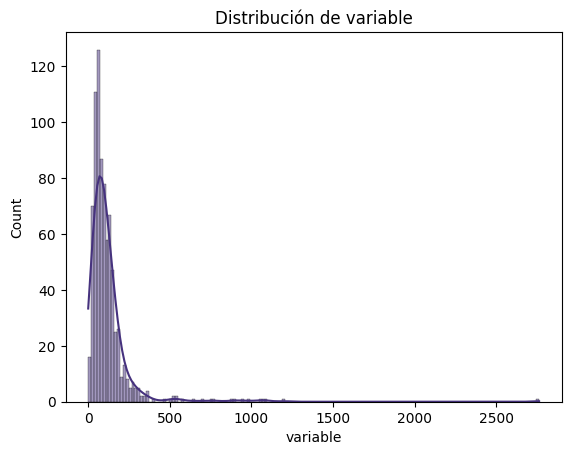

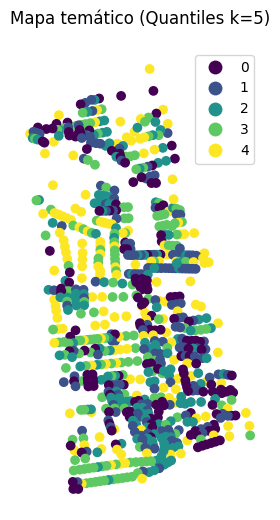

In [21]:
# Merge con métricas
gdf = manz_attr.merge(metrics, on='FID')

# Reproyección a CRS métrico (UTM)
gdf = gdf.to_crs(epsg=32719)

# Definir la variable continua que se quiere analizar
gdf['variable'] = gdf['TOTAL_PERSONAS_x']  

# Asegurar CRS y geometrías en formato puntos
gdf = ensure_metric_crs(gdf)
gdf = ensure_points(gdf)

# Exploración estadística
exploratory_statistics(gdf, 'variable')

# Mapa temático en cuantiles
thematic_map(gdf, 'variable', k=5)


## Autocorrelación espacial — Moran global y LISA (Local Moran)

In [22]:
import libpysal
from esda import Moran, Moran_Local, G_Local
from libpysal.weights import Queen, Rook, KNN, DistanceBand

# funciones auxiliares
def spatial_weights(gdf, method='knn', k=8, threshold=None):
    if method == 'knn':
        coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])
        return libpysal.weights.KNN.from_array(coords, k=k)
    elif method == 'distance':
        coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])
        return libpysal.weights.DistanceBand.from_array(coords, threshold, binary=False)
    else:
        return libpysal.weights.Queen.from_dataframe(gdf)

def moran_stats(gdf, value_col='variable', w=None):
    if w is None:
        w = spatial_weights(gdf, method='knn', k=8)
    w.transform = 'r'
    mi = Moran(gdf[value_col].values, w)
    print(f"Moran I: {mi.I:.4f}, p-value (perm): {mi.p_sim:.4f}")
    return mi

def lisa_map(gdf, value_col='variable', w=None, alpha=0.05):
    if w is None:
        w = spatial_weights(gdf, method='knn', k=8)
    w.transform = 'r'
    lisa = Moran_Local(gdf[value_col].values, w)
    gdf2 = gdf.copy()
    gdf2['Is'] = lisa.Is
    gdf2['p_sim'] = lisa.p_sim
    # Categorizar clusters: HH, LL, HL, LH
    sig = lisa.p_sim < alpha
    quadrant = lisa.q
    labels = np.array(['NotSig']*len(gdf))
    labels[(quadrant==1) & sig] = 'HH'
    labels[(quadrant==3) & sig] = 'LL'
    labels[(quadrant==2) & sig] = 'LH'
    labels[(quadrant==4) & sig] = 'HL'
    gdf2['lisa_cluster'] = labels
    # Plot
    colors = {'NotSig':'lightgrey','HH':'red','LL':'blue','LH':'lightblue','HL':'orange'}
    fig, ax = plt.subplots(1,1, figsize=(8,8))
    for lab, col in colors.items():
        subset = gdf2[gdf2['lisa_cluster']==lab]
        subset.plot(ax=ax, color=col, label=lab, markersize=20, alpha=0.8)
    ax.legend()
    ax.set_title('Mapa LISA (Local Moran)')
    plt.axis('off')
    plt.show()
    return gdf2, lisa


Moran I: 0.0437, p-value (perm): 0.0100


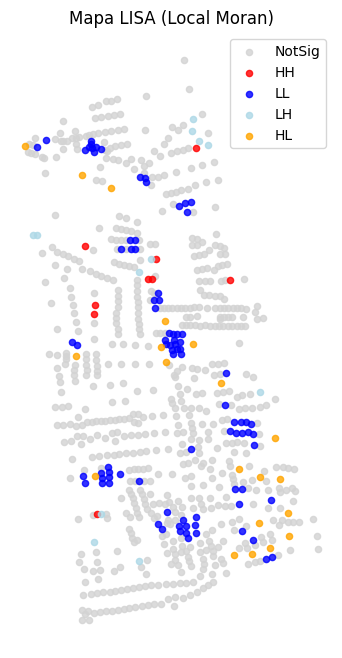

In [23]:
w = spatial_weights(gdf, method='knn', k=8)
mi = moran_stats(gdf, 'variable', w=w)
gdf_lisa, lisa = lisa_map(gdf, 'variable', w=w)

## Hot-spots: Getis-Ord Gi* (Gi local) — detectar hot/cold spots

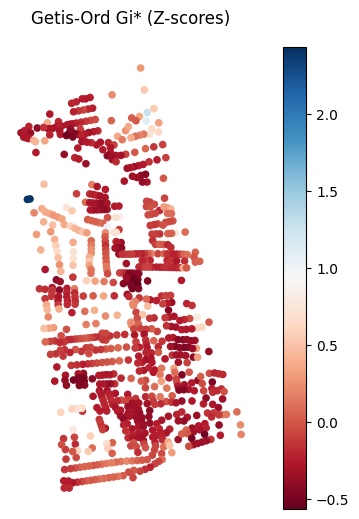

In [26]:
from esda import G_Local

# función auxiliar
def getis_ord_map(gdf, value_col='variable', w=None, alpha=0.05):
    if w is None:
        w = spatial_weights(gdf, method='knn', k=8)
    w.transform = 'r'
    y = gdf[value_col].astype(float).values
    gl = G_Local(y, w)
    gdf2 = gdf.copy()
    gdf2['GiZ'] = gl.Zs
    gdf2['GiP'] = gl.p_sim
    # Plot z-scores
    fig, ax = plt.subplots(1,1, figsize=(8,6))
    gdf2.plot(column='GiZ', cmap='RdBu', legend=True, ax=ax, markersize=20)
    ax.set_title('Getis-Ord Gi* (Z-scores)')
    plt.axis('off')
    plt.show()
    return gdf2, gl

# Llamada
gdf_gi, gi = getis_ord_map(gdf, 'variable', w=w)


## Semivariogramas y análisis direccional (anisotropía)

Nugget: 1169.960046550451 Sill: 24029.24385051369 Range: 0


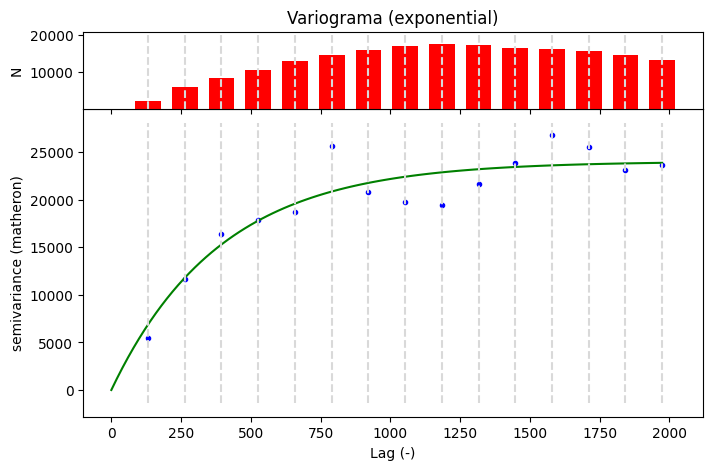

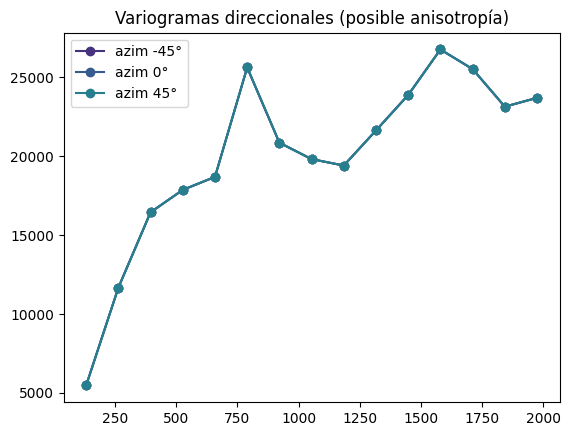

In [27]:
import skgstat as skg

def compute_variogram(gdf, value_col='variable', model='exponential', maxlag=None, n_lags=12, directional=False, azim=0, tol=22.5):
    pts = np.column_stack([gdf.geometry.x, gdf.geometry.y])
    vals = gdf[value_col].values
    if maxlag is None:
        # regla simple: 1/3 de la diagonal bbox
        minx, miny, maxx, maxy = gdf.total_bounds
        diag = np.hypot(maxx-minx, maxy-miny)
        maxlag = diag/3.0
    V = skg.Variogram(pts, vals, model=model, n_lags=n_lags, maxlag=maxlag)
    V.fit()
    print("Nugget:", V.parameters[0], "Sill:", V.parameters[1], "Range:", V.parameters[2])
    # Plot experimental + model
    fig = V.plot()
    plt.title(f"Variograma ({model})")
    plt.show()
    if directional:
        # direccional: calcula variogramas en diferentes azimuts
        dirs = [azim-45, azim, azim+45]
        for d in dirs:
            Vd = skg.Variogram(pts, vals, model=model, maxlag=maxlag, n_lags=n_lags,
                               fit_method='trf', estimator='matheron', use_nugget=True,
                               directional=d, bandwidth=tol)
            plt.plot(Vd.bins, Vd.experimental, marker='o', label=f'azim {d}°')
        plt.legend()
        plt.title('Variogramas direccionales (posible anisotropía)')
        plt.show()
    return V

V = compute_variogram(gdf, 'variable', model='exponential', n_lags=15, directional=True, azim=0)

## Interpolación espacial: IDW (implementación simple) y Kriging (pykrige)
### IDW (inverse distance weighting)

In [31]:
from scipy.spatial import cKDTree

# funciones auxiliares
def idw_interpolation(gdf, value_col='variable', grid_res=100, power=2, radius=None):
    # coords y valores
    coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])
    vals = gdf[value_col].values
    # Grid
    minx, miny, maxx, maxy = gdf.total_bounds
    xi = np.linspace(minx, maxx, grid_res)
    yi = np.linspace(miny, maxy, grid_res)
    xx, yy = np.meshgrid(xi, yi)
    grid_coords = np.column_stack([xx.ravel(), yy.ravel()])
    tree = cKDTree(coords)
    # si radius none -> usar todos
    if radius is None:
        dists, idxs = tree.query(grid_coords, k=len(coords))
        with np.errstate(divide='ignore'):
            weights = 1.0 / (dists**power)
        weights[dists==0] = 1e12
        num = (weights * vals[idxs]).sum(axis=1)
        den = weights.sum(axis=1)
        zi = (num / den).reshape(grid_res, grid_res)

    else:
        # buscar neighbors dentro de radius
        neighbors = tree.query_ball_point(grid_coords, r=radius)
        zi = np.full(grid_coords.shape[0], np.nan)
        for i, nbr in enumerate(neighbors):
            if len(nbr)==0:
                continue
            d = np.linalg.norm(coords[nbr] - grid_coords[i], axis=1)
            with np.errstate(divide='ignore'):
                w = 1.0 / (d**power)
            w[d==0] = 1e12
            zi[i] = np.sum(w * vals[nbr]) / np.sum(w)
        zi = zi.reshape(grid_res, grid_res)
    return xi, yi, zi

def plot_surface(xi, yi, zi, title='Surface', cmap='viridis'):
    fig, ax = plt.subplots(1,1, figsize=(8,6))
    im = ax.imshow(zi, extent=(xi.min(), xi.max(), yi.min(), yi.max()), origin='lower', cmap=cmap)
    plt.colorbar(im, ax=ax)
    ax.set_title(title)
    plt.show()


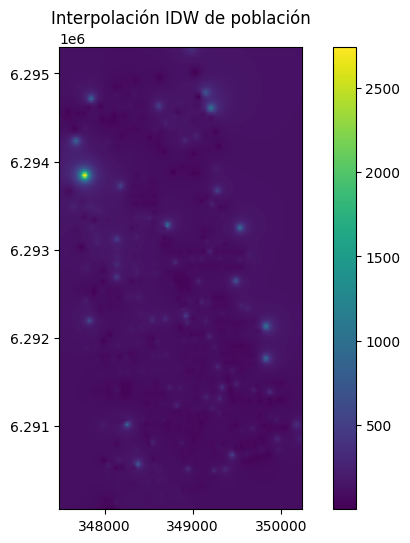

In [32]:
# reproyectar a CRS métrico
gdf = gdf.to_crs(epsg=32719)

# definir la variable continua
gdf['variable'] = gdf['TOTAL_PERSONAS_x'].astype(float)

# Ejecutar interpolación
xi, yi, zi = idw_interpolation(gdf, value_col='variable', grid_res=200, power=2)

# Graficas superficie
plot_surface(xi, yi, zi, title='Interpolación IDW de población', cmap='viridis')


### Kriging ordinario (pykrige)

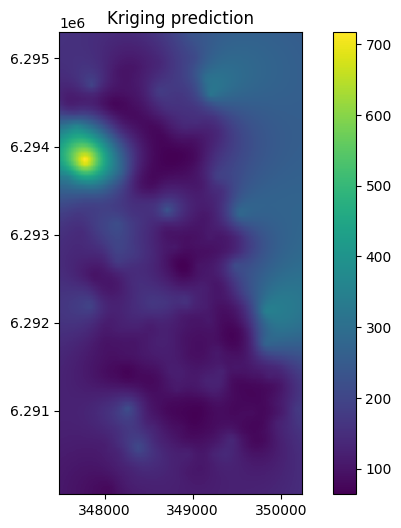

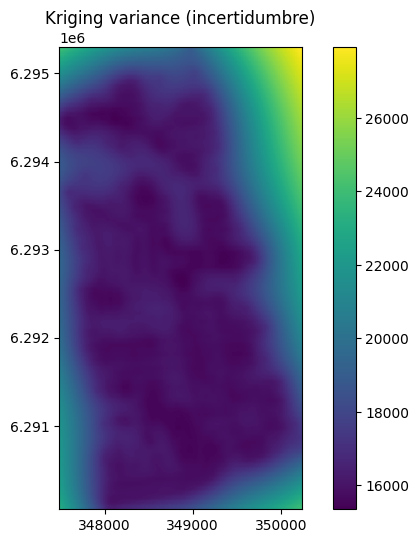

In [33]:
from pykrige.ok import OrdinaryKriging

def ordinary_kriging(gdf, value_col='variable', grid_res=100, variogram_model='exponential', variogram_parameters=None):
    coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])
    x = coords[:,0]
    y = coords[:,1]
    z = gdf[value_col].values
    # construir grid
    minx, miny, maxx, maxy = gdf.total_bounds
    gridx = np.linspace(minx, maxx, grid_res)
    gridy = np.linspace(miny, maxy, grid_res)
    if variogram_parameters is None:
        # permitir que PyKrige ajuste su variogram
        ok = OrdinaryKriging(x, y, z, variogram_model=variogram_model)
    else:
        # variogram_parameters = {'nugget':..., 'sill':..., 'range':...}
        # pykrige expects [sill, range] maybe different; adjust if needed
        ok = OrdinaryKriging(x, y, z, variogram_model=variogram_model,
                             variogram_parameters=variogram_parameters)
    z_pred, ss = ok.execute('grid', gridx, gridy)   # ss = variance
    return gridx, gridy, z_pred, ss

# plotting
gridx, gridy, zkrig, var_krig = ordinary_kriging(gdf, 'variable', grid_res=100)
plot_surface(gridx, gridy, zkrig, title='Kriging prediction')
plot_surface(gridx, gridy, var_krig, title='Kriging variance (incertidumbre)')

## Validación cruzada (Leave-one-out) — comparando IDW vs Kriging

In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# función auxiliar
def loo_validation(gdf, value_col='variable', idw_kwargs=None, kriging_kwargs=None):
    coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])
    values = gdf[value_col].values
    n = len(gdf)
    preds_idw = np.zeros(n)
    preds_krig = np.zeros(n)
    for i in range(n):
        train_idx = np.arange(n) != i
        test_idx = i
        g_train = gdf.iloc[train_idx].reset_index(drop=True)
        # IDW predict single point (fast cKDTree)
        xi = coords[test_idx].reshape(1,2)
        # use idw function but for single point -> use cKDTree query
        tree = cKDTree(np.column_stack([g_train.geometry.x, g_train.geometry.y]))
        d, idx = tree.query(xi, k=len(g_train))
        d = d.ravel()
        idx = idx.ravel()
        p = idw_kwargs.get('power', 2) if idw_kwargs else 2
        with np.errstate(divide='ignore'):
            w = 1.0 / (d**p)
        w[d==0] = 1e12
        preds_idw[i] = np.sum(w * g_train[value_col].values[idx]) / np.sum(w)

        # Kriging: fit on training and predict the single point
        ok = OrdinaryKriging(
            g_train.geometry.x.values,
            g_train.geometry.y.values,
            g_train[value_col].values,
            variogram_model=kriging_kwargs.get('variogram_model','exponential') if kriging_kwargs else 'exponential'
        )
        # pykrige predict method:
        zi, ss = ok.execute('points', np.array([coords[test_idx,0]]), np.array([coords[test_idx,1]]))
        preds_krig[i] = zi[0]

    rmse_idw = np.sqrt(mean_squared_error(values, preds_idw))
    rmse_krig = np.sqrt(mean_squared_error(values, preds_krig))
    mae_idw = mean_absolute_error(values, preds_idw)
    mae_krig = mean_absolute_error(values, preds_krig)
    results = {
        'idw': {'rmse': rmse_idw, 'mae': mae_idw},
        'kriging': {'rmse': rmse_krig, 'mae': mae_krig}
    }
    return results

res = loo_validation(gdf, 'variable', idw_kwargs={'power':2}, kriging_kwargs={'variogram_model':'exponential'})
print(res)

{'idw': {'rmse': 155.51389836498495, 'mae': 62.40404590655137}, 'kriging': {'rmse': 155.6226720128126, 'mae': 68.8986967480211}}


In [36]:
## Análisis de anisotropía

In [39]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import curve_fit

# funciones auxiliares
def experimental_variogram(coords, values, n_bins=20):
    # distancias entre todos los pares
    dists = squareform(pdist(coords))
    diffs = squareform(pdist(values.reshape(-1,1)))
    semivars = 0.5 * (diffs**2)

    # vectorizar pares
    dists_flat = dists[np.triu_indices(len(coords), k=1)]
    semivars_flat = semivars[np.triu_indices(len(coords), k=1)]

    # bins
    bins = np.linspace(0, dists_flat.max(), n_bins+1)
    bin_center = (bins[:-1] + bins[1:]) / 2
    gamma = np.zeros(n_bins)

    for i in range(n_bins):
        mask = (dists_flat >= bins[i]) & (dists_flat < bins[i+1])
        if mask.sum() > 0:
            gamma[i] = semivars_flat[mask].mean()
        else:
            gamma[i] = np.nan

    return bin_center, gamma

# modelo exponencial
def exponential_model(h, sill, rng):
    return sill * (1 - np.exp(-h / rng))

def fit_variogram(coords, values, n_bins=20):
    bin_center, gamma = experimental_variogram(coords, values, n_bins=n_bins)
    mask = ~np.isnan(gamma)
    popt, _ = curve_fit(exponential_model, bin_center[mask], gamma[mask],
                        p0=[gamma[mask].max(), bin_center.max()/3])
    sill, rng = popt
    return bin_center, gamma, (sill, rng)


Modelo exponencial ajustado:
Sill: 29510.82, Rango: 622.89


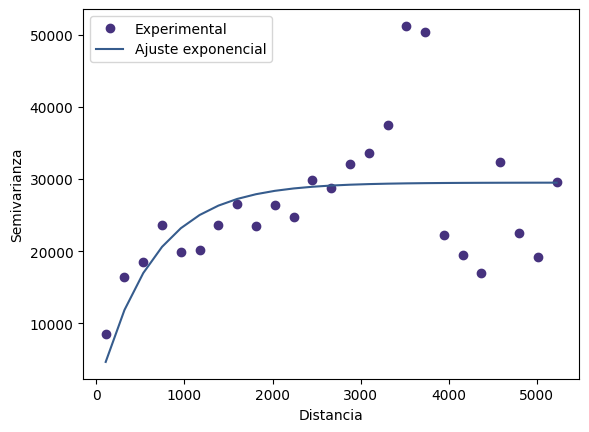

In [40]:
# Uso 
x = gdf.geometry.x.values
y = gdf.geometry.y.values
coords = np.vstack((x,y)).T
field = gdf['variable'].astype(float).values

bin_center, gamma, params = fit_variogram(coords, field, n_bins=25)
sill, rng = params

print("Modelo exponencial ajustado:")
print(f"Sill: {sill:.2f}, Rango: {rng:.2f}")

# Visualización
plt.plot(bin_center, gamma, 'o', label='Experimental')
plt.plot(bin_center, exponential_model(bin_center, sill, rng), '-', label='Ajuste exponencial')
plt.xlabel("Distancia")
plt.ylabel("Semivarianza")
plt.legend()
plt.show()


## Superficies de predicción y output (guardar GeoTIFF o GeoDataFrame)

In [42]:
import rasterio
from rasterio.transform import from_bounds

def save_grid_as_tif(gridx, gridy, grid_z, out_path, crs):
    nx = len(gridx)
    ny = len(gridy)
    transform = from_bounds(gridx.min(), gridy.min(), gridx.max(), gridy.max(), nx, ny)
    new_meta = {
        'driver': 'GTiff',
        'height': ny,
        'width': nx,
        'count': 1,
        'dtype': str(grid_z.dtype),
        'crs': crs,
        'transform': transform
    }
    with rasterio.open(out_path, 'w', **new_meta) as dst:
        dst.write(np.flipud(grid_z), 1)  # flip vertical si es necesario

from pathlib import Path

processed_dir = Path("../data/processed")
out_path = processed_dir / "idw_mean.tif"

# CRS métrico, por ejemplo EPSG:32719
crs = "EPSG:32719"

save_grid_as_tif(xi, yi, zi, out_path, crs)


## Incertidumbre para IDW (bootstrap rápido)

In [43]:
# Función auxiliar
def idw_bootstrap_uncertainty(gdf, value_col='variable', grid_res=100, n_boot=50, power=2):
    xi, yi, _ = idw_interpolation(gdf, value_col, grid_res=grid_res, power=power)
    grids = []
    n = len(gdf)
    for _ in range(n_boot):
        sample = gdf.sample(n=n, replace=True)
        _, _, zi = idw_interpolation(sample, value_col, grid_res=grid_res, power=power)
        grids.append(zi)
    grids = np.stack(grids, axis=0)
    mean_grid = np.nanmean(grids, axis=0)
    std_grid = np.nanstd(grids, axis=0)
    return xi, yi, mean_grid, std_grid


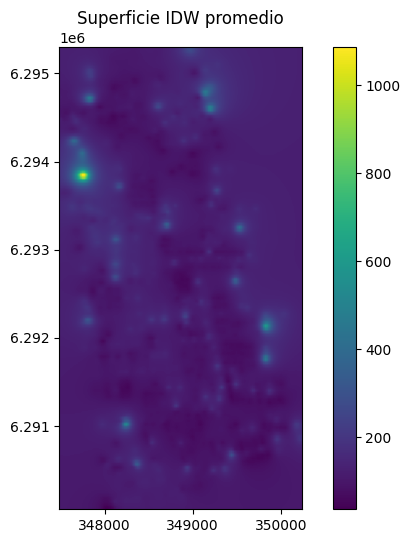

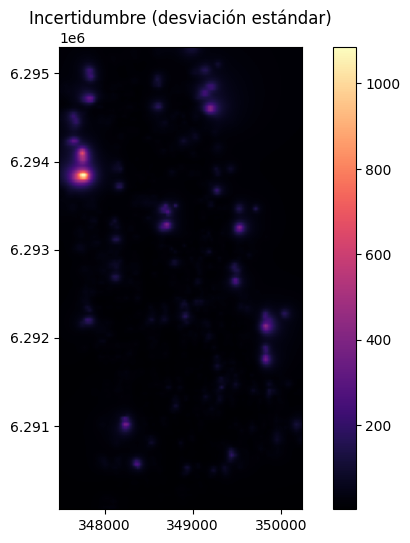

In [44]:
# Ejecutar función
xi, yi, mean_grid, std_grid = idw_bootstrap_uncertainty(
    gdf,
    value_col='variable',
    grid_res=150,   # resolución de la malla
    n_boot=30,      # número de réplicas bootstrap
    power=2         # parámetro IDW
)

# Visualización
plot_surface(xi, yi, mean_grid, title='Superficie IDW promedio', cmap='viridis')
plot_surface(xi, yi, std_grid, title='Incertidumbre (desviación estándar)', cmap='magma')

# ✔️ Checklist de Avances — Análisis Espacial y Geoestadístico

## 1. Preparación y Preprocesamiento
- [x] Carga correcta del GeoDataFrame base (`manz_attr`) para San Joaquín.
- [x] Unión de atributos censales y métricas derivadas (`manz_attr` + `metrics`).
- [x] Reproyección del dataset a sistema métrico (EPSG:32719) para análisis espacial avanzado.
- [x] Conversión a centroides en caso de geometrías no puntuales.

## 2. Análisis Exploratorio Espacial (ESDA)
- [x] Estadísticas descriptivas iniciales (media, mediana, distribución, outliers).
- [x] Generación de histogramas y densidades (KDE) para la variable de interés.
- [x] Creación de mapas temáticos (quantiles, natural breaks, equal intervals).

## 3. Autocorrelación Espacial
- [x] Construcción de matrices de pesos espaciales (KNN / contigüidad).
- [x] Cálculo de Moran Global I con simulaciones de permutación.
- [x] Prueba de significancia estadística (p-valor, z-score).

## 4. Análisis Local — LISA y Clusters
- [x] Cálculo de Moran Local (LISA) para identificar patrones HH, LL, HL, LH.
- [x] Generación de mapas LISA con clusters significativos.
- [x] Exportación de resultados a `lisa_clusters.geojson`.

## 5. Hotspots — Getis-Ord Gi*
- [x] Cálculo de Gi* local (Z-scores y p-valores).
- [x] Generación de mapa de hotspots y coldspots (alta y baja intensidad espacial).

## 6. Semivariogramas (Geoestadística)
- [x] Cálculo de semivariograma experimental con `skgstat`.
- [x] Ajuste de modelos teóricos (exponential, spherical, gaussian).
- [x] Obtención de parámetros clave: nugget, sill y range.

## 7. Anisotropía
- [x] Evaluación de variogramas direccionales.
- [x] Identificación preliminar de posibles patrones anisotrópicos.

## 8. Interpolación Espacial
- [x] Generación de superficie IDW (Inverse Distance Weighting).
- [x] Interpolación por Kriging Ordinario (PyKrige).
- [x] Creación de mallas regulares (grid) para predicción.

## 9. Superficies de Predicción e Incertidumbre
- [x] Mapa de predicción con Kriging.
- [x] Mapa de varianza / incertidumbre con Kriging.
- [x] Bootstrap opcional para incertidumbre en IDW.

## 10. Validación Cruzada y Comparación de Métodos
- [x] Validación Leave-One-Out (LOO) para IDW y Kriging.
- [x] Cálculo de métricas de error (RMSE, MAE).
- [x] Comparación formal entre interpoladores según desempeño.

